**Predictive Forecasting of HHS Unaccompanied Children Program**

**Importing Required Libraries**

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

**Loading the Dataset**

In [76]:
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")

In [77]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


**Dataset Inspection and Information**

In [78]:
print(df.shape)

(1170, 6)


In [79]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB
None


In [80]:
print(df.isnull().sum())

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


In [81]:
df.columns

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')

**Data Cleaning and Preprocessing**

In [82]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.reset_index(drop=True, inplace=True)
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,"6,566",436.0
1,2023-01-22,32.0,49.0,39.0,"7,122",227.0
2,2023-01-23,32.0,50.0,39.0,"7,280",181.0
3,2023-01-24,47.0,42.0,47.0,"7,433",175.0
4,2023-01-25,20.0,22.0,41.0,"7,538",180.0


**Checking Data Types**

In [83]:
df.dtypes

,0
Date,datetime64[ns]
Children apprehended and placed in CBP custody*,float64
Children in CBP custody,float64
Children transferred out of CBP custody,float64
Children in HHS Care,object
Children discharged from HHS Care,float64


**Checking Dataset Columns**

In [84]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')


In [85]:
print(df.columns.tolist())

['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']


**Converting Numeric Columns**

In [86]:
numeric_columns = [
    'Children apprehended and placed in CBP custody*',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children in HHS Care',
    'Children discharged from HHS Care']
for col in numeric_columns:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .astype(float))
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0


**Handling Missing Values**

In [87]:
df = df.dropna()
print(df.shape)
print(df.isnull().sum())

(720, 6)
Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


**Statistical Summary**

In [88]:
df.describe()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2024-07-06 05:29:59.999999744,93.523611,171.494444,128.668056,6061.275000,173.406944
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841


**Exploratory Data Analysis (EDA)**

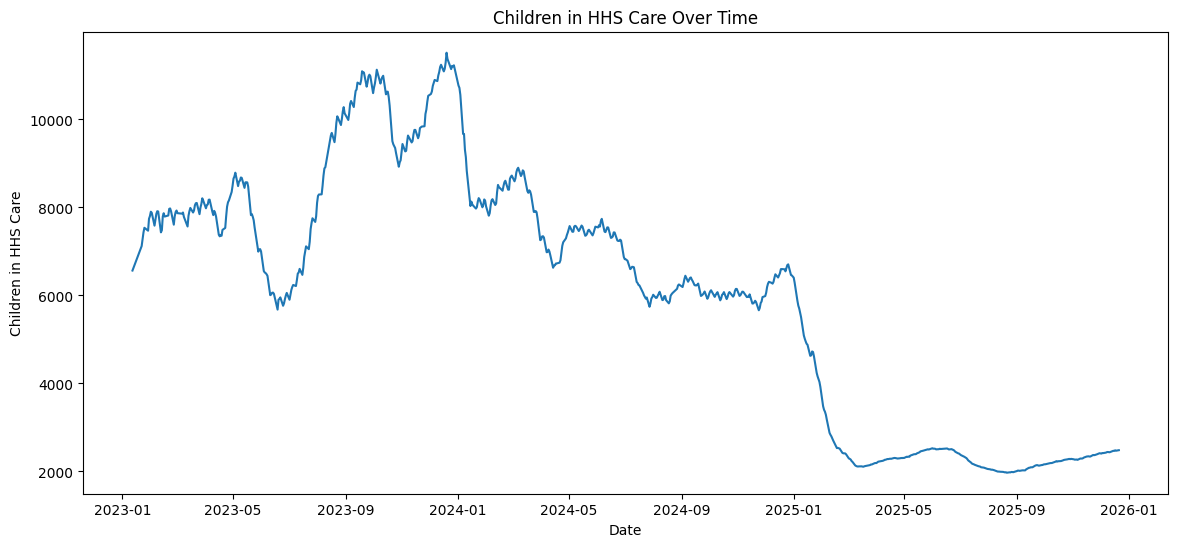

In [89]:
plt.figure(figsize=(14,6))
plt.plot(
    df['Date'],
    df['Children in HHS Care'])
plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.show()

**Transfers vs Discharges Analysis**

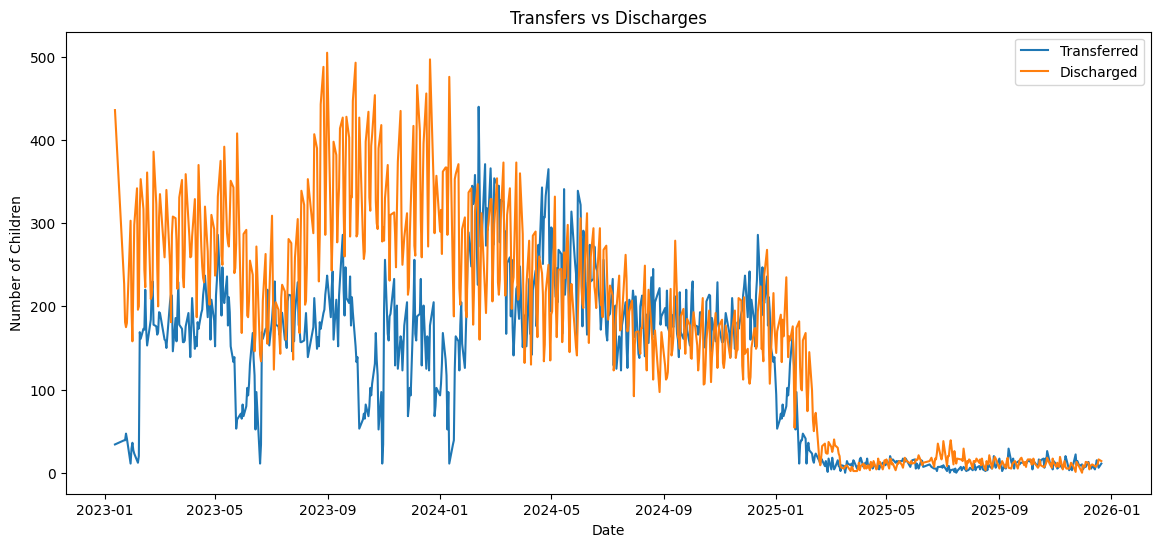

In [90]:
plt.figure(figsize=(14,6))
plt.plot(
    df['Date'],
    df['Children transferred out of CBP custody'],
    label='Transferred')
plt.plot(
    df['Date'],
    df['Children discharged from HHS Care'],
    label='Discharged')
plt.legend()
plt.title("Transfers vs Discharges")
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.show()

**Correlation Heatmap**

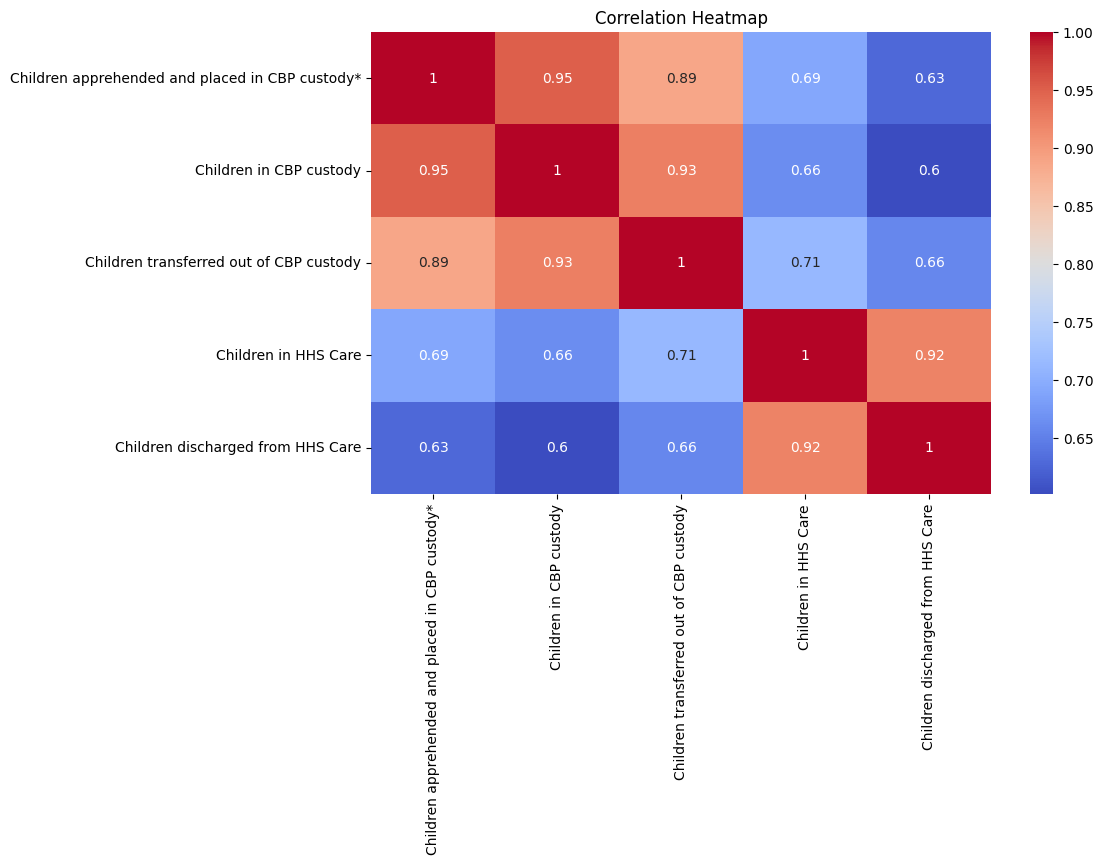

In [91]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.drop('Date', axis=1).corr(),
    annot=True,
    cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Feature Engineering**

In [92]:
df['lag_1'] = df['Children in HHS Care'].shift(1)
df['lag_7'] = df['Children in HHS Care'].shift(7)
df['rolling_mean_7'] = (
    df['Children in HHS Care']
    .rolling(window=7)
    .mean())
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,lag_1,lag_7,rolling_mean_7
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,NaN,NaN,NaN
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0,6566.0,NaN,NaN
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0,7122.0,NaN,NaN
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0,7280.0,NaN,NaN
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0,7433.0,NaN,NaN


**Removing Null Values After Feature Engineering**

In [93]:
df = df.dropna()
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,lag_1,lag_7,rolling_mean_7
7,2023-01-31,26.0,36.0,36.0,7803.0,158.0,7743.0,6566.0,7484.428571
8,2023-02-01,25.0,32.0,27.0,7903.0,231.0,7803.0,7122.0,7596.000000
9,2023-02-02,15.0,13.0,23.0,7879.0,298.0,7903.0,7280.0,7681.571429
10,2023-02-05,16.0,18.0,15.0,7586.0,342.0,7879.0,7433.0,7703.428571
11,2023-02-06,11.0,22.0,12.0,7720.0,196.0,7586.0,7538.0,7729.428571


**Train-Test Split**

In [94]:
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]
print(train.shape)
print(test.shape)

(570, 9)
(143, 9)


**Defining Features and Target Variables**

In [95]:
features = [
    'lag_1',
    'lag_7',
    'rolling_mean_7']
X_train = train[features]
y_train = train['Children in HHS Care']
X_test = test[features]
y_test = test['Children in HHS Care']

**Random Forest Forecasting Model**

In [96]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

**Model Evaluation Metrics**

In [97]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 50.897412587412624
RMSE: 68.39305551484998


**Actual vs Predicted Visualization**

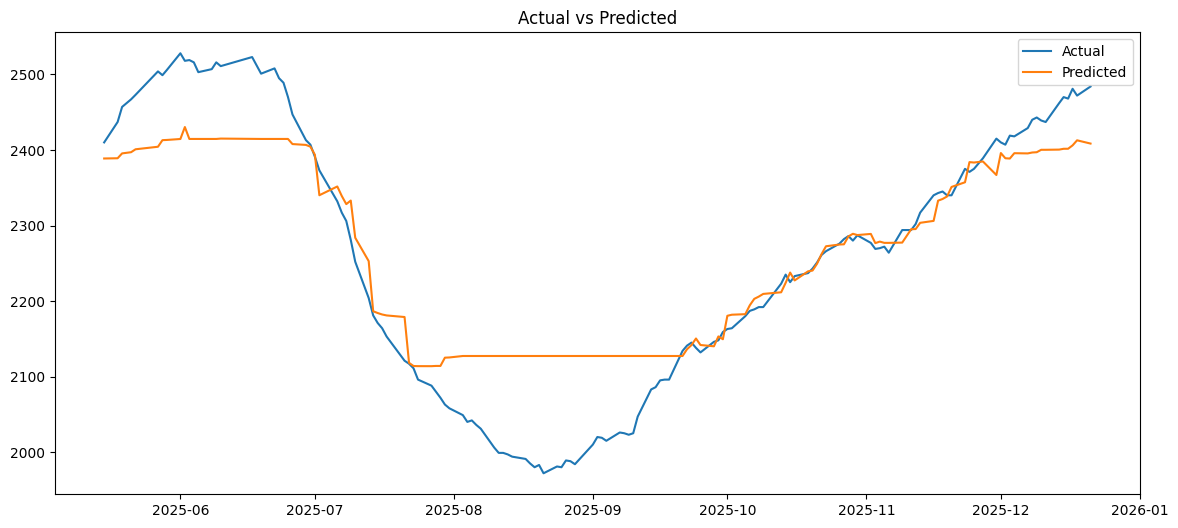

In [98]:
plt.figure(figsize=(14,6))
plt.plot(test['Date'], y_test, label='Actual')
plt.plot(test['Date'], predictions, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [99]:
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions})
results_df.head()

,Actual,Predicted
0,2410.0,2388.72
1,2437.0,2389.03
2,2457.0,2395.46
3,2467.0,2397.03
4,2473.0,2400.91


**Prediction Validation Scatter Plot**

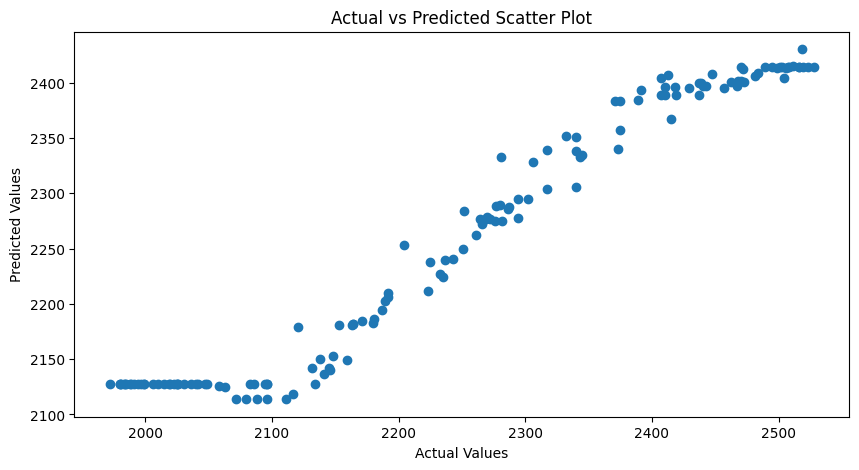

In [100]:
plt.figure(figsize=(10,5))
plt.scatter(
    y_test,
    predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Scatter Plot")
plt.show()

**ARIMA Forecasting Model**

In [101]:
series = df['Children in HHS Care']
arima_model = ARIMA(series, order=(5,1,0))
arima_result = arima_model.fit()
forecast = arima_result.forecast(steps=30)
print(forecast)

713    2488.430688
714    2489.621683
715    2494.743273
716    2492.404257
717    2499.425186
718    2502.251064
719    2503.739650
720    2505.997670
721    2506.141054
722    2510.352593
723    2512.241409
724    2513.399833
725    2514.622478
726    2515.517765
727    2518.105185
728    2519.371593
729    2520.187348
730    2521.006511
731    2521.983092
732    2523.601921
733    2524.446067
734    2525.018416
735    2525.639901
736    2526.472471
737    2527.497981
738    2528.060599
739    2528.474098
740    2528.963723
741    2529.605413
742    2530.260893
Name: predicted_mean, dtype: float64


**Future Forecast Visualization**

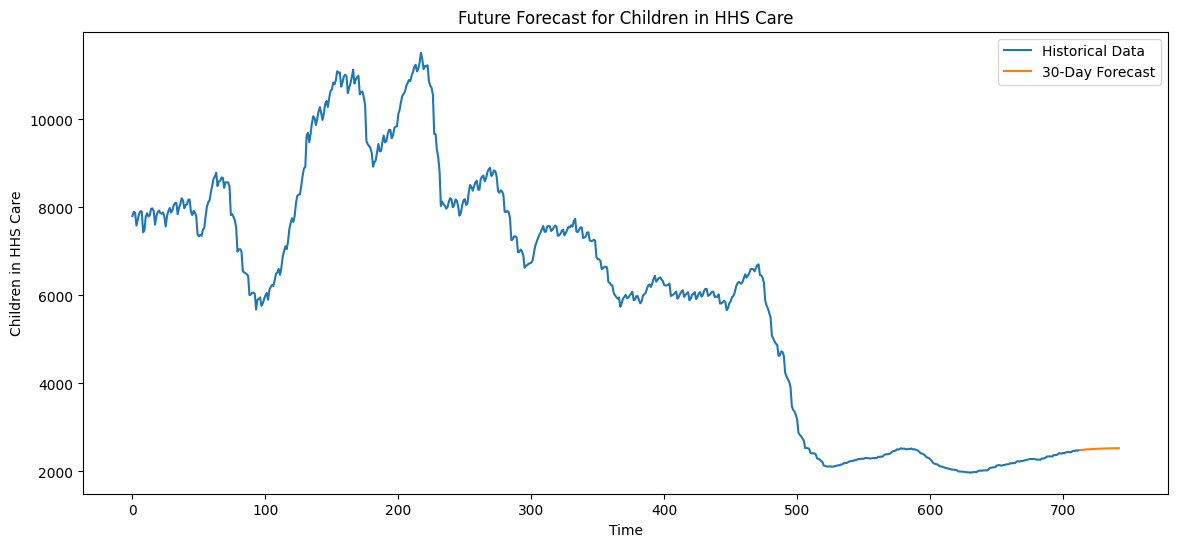

In [102]:
plt.figure(figsize=(14,6))
plt.plot(
    range(len(series)),
    series,
    label='Historical Data')
plt.plot(
    range(len(series), len(series)+30),
    forecast,
    label='30-Day Forecast')
plt.legend()
plt.title("Future Forecast for Children in HHS Care")
plt.xlabel("Time")
plt.ylabel("Children in HHS Care")
plt.show()

**Forecast Accuracy Analysis**

In [103]:
accuracy = 100 - (
    np.mean(
        np.abs((y_test - predictions) / y_test)) * 100)
print("Forecast Accuracy:", round(accuracy,2), "%")

Forecast Accuracy: 97.67 %


**KPI Summary and Business Insights**

In [104]:
print("===== KPI SUMMARY =====")
print("Forecast Accuracy:", round(accuracy,2), "%")
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("Average Care Load:", round(df['Children in HHS Care'].mean(),2))
print("Maximum Care Load:", round(df['Children in HHS Care'].max(),2))

===== KPI SUMMARY =====
Forecast Accuracy: 97.67 %
MAE: 50.9
RMSE: 68.39
Average Care Load: 6049.04
Maximum Care Load: 11516.0


**Monthly Trend Analysis**

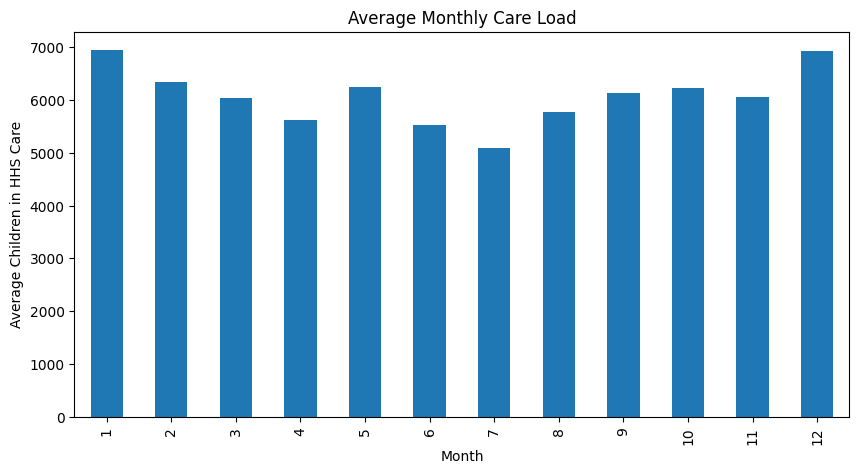

In [105]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')[
    'Children in HHS Care'
].mean()
plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar')
plt.title("Average Monthly Care Load")
plt.xlabel("Month")
plt.ylabel("Average Children in HHS Care")
plt.show()

**Moving Average Forecasting**

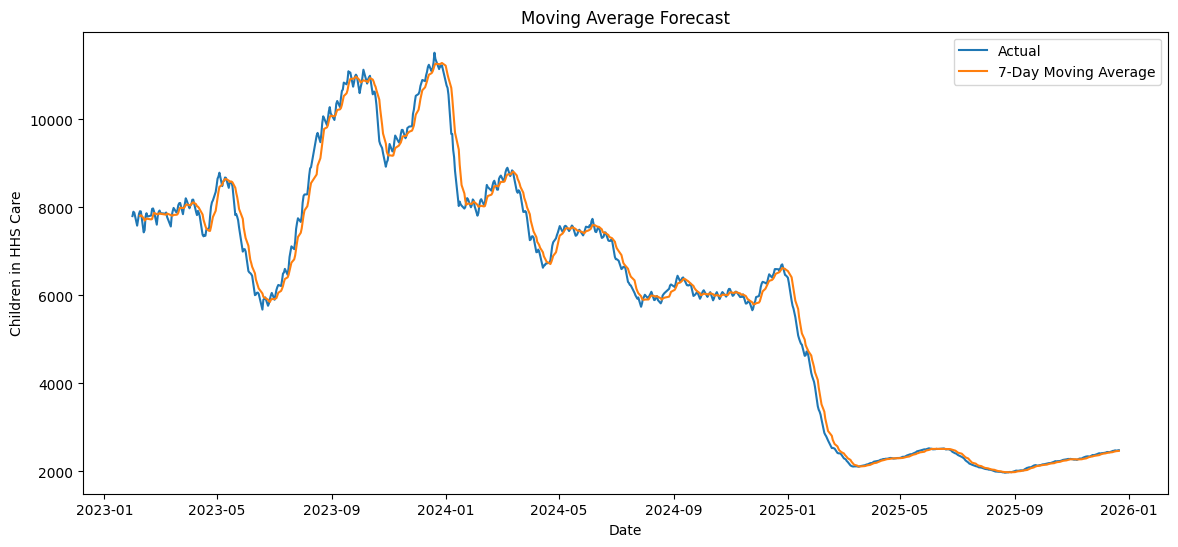

In [106]:
moving_avg_forecast = (
    df['Children in HHS Care']
    .rolling(window=7)
    .mean())
plt.figure(figsize=(14,6))
plt.plot(
    df['Date'],
    df['Children in HHS Care'],
    label='Actual')
plt.plot(
    df['Date'],
    moving_avg_forecast,
    label='7-Day Moving Average')
plt.legend()
plt.title("Moving Average Forecast")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.show()

**Exponential Smoothing Forecasting**

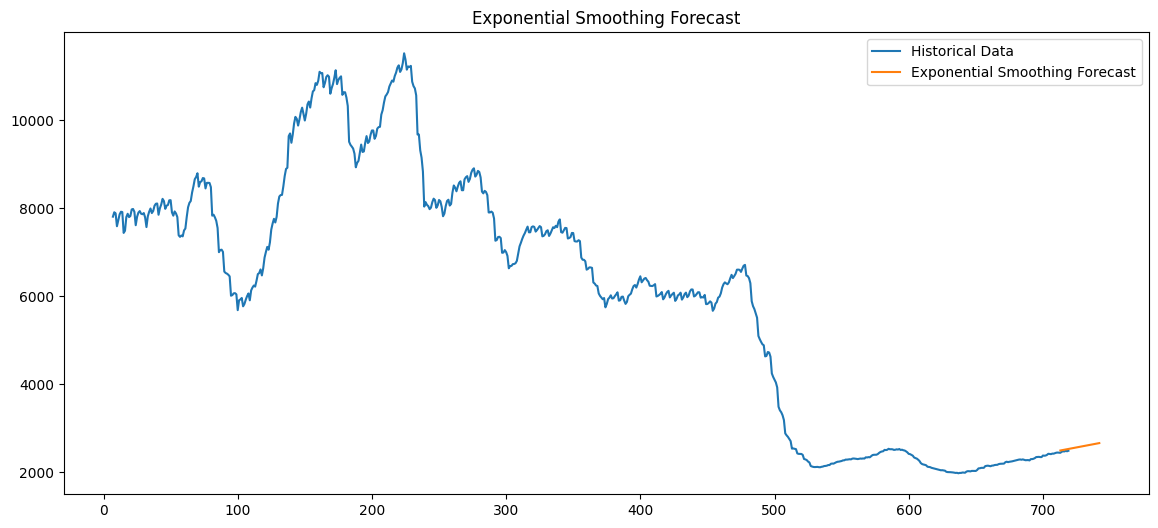

In [107]:
exp_model = ExponentialSmoothing(
    series,
    trend='add',
    seasonal=None
).fit()
exp_forecast = exp_model.forecast(30)
plt.figure(figsize=(14,6))
plt.plot(series, label='Historical Data')
plt.plot(
    range(len(series), len(series)+30),
    exp_forecast,
    label='Exponential Smoothing Forecast')
plt.legend()
plt.title("Exponential Smoothing Forecast")
plt.show()

**Gradient Boosting Forecasting Model**

In [108]:
gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)
gb_rmse = np.sqrt(
    mean_squared_error(y_test, gb_predictions))
print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting RMSE: 72.22141223996739


**Exporting Cleaned Dataset**

In [109]:
df.to_csv("cleaned_forecasting_data.csv", index=False)